# Plot Annual Mean PM<sub>2.5</sub> difference between scenarios

Using SHERPA values

In [7]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure
import config
from utils.utils import require_dir
import pathlib

In [14]:
def load_pm25(scenario, year):
    # === Path config ===
    PM25_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "SHERPA" / "processed")

    file = f"EU_concentration_{scenario}_{year}.nc"
    path = os.path.join(PM25_DIR, file)
    da = xr.open_dataarray(path)

    return da

In [9]:
def plot_annual_pm25_diff(das, scenario, scen_name, select_scenario, years, SAVE_DIR):
    fig = plt.figure(figsize=autosize_figure(2, 2, yscale_factor=1.3))
    # 2 rows x 2 map columns + 1 narrow colorbar column spanning both rows
    gs = GridSpec(2, 3, width_ratios=[15, 15, 1], height_ratios=[1, 1])

    # Map projection and display
    projection = ccrs.EuroPP()
    crs = ccrs.PlateCarree()
    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='10m',
        facecolor='none')
    cmap = plt.get_cmap("RdBu_r")

    # Shared symmetric scale across all four years — computed once from the global extremes
    vabs = max(
        max(abs(da.min(skipna=True).item()), abs(da.max(skipna=True).item()))
        for da in das
    )
    linthresh = 1
    norm = SymLogNorm(linthresh=linthresh, vmin=-vabs, vmax=vabs, base=10)

    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for (r, c), da, year in zip(positions, das, years):
        ax = fig.add_subplot(gs[r, c], projection=projection, frameon=True)
        cb = da.plot(ax=ax, transform=crs, add_colorbar=False, cmap=cmap, norm=norm)
        ax.add_feature(country_borders, edgecolor='white', alpha=0.5, linewidth=0.75)
        ax.set_title(f"{year}")
    fig.suptitle(f"{scen_name} minus {select_scenario}", y=0.98)

    # Shared colorbar spanning both rows
    cax = fig.add_subplot(gs[:, 2])
    col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
    col_bar.set_label("Difference in PM$_{2.5}$", fontsize=16)
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    #candidate_ticks = [-1000, -100, -10, -1, 0, 1, 10, 100, 1000]
    #ticks = [t for t in candidate_ticks if -vabs <= t <= vabs]
    #if len(ticks) < 2:
    #    ticks = np.linspace(-vabs, vabs, 5)
    #col_bar.set_ticks(ticks)
    col_bar.ax.yaxis.set_major_formatter(formatter)
    plt.tight_layout()
    out_file = f"Annual_PM25_diff_{scenario}-{select_scenario}_grid.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path)
    return

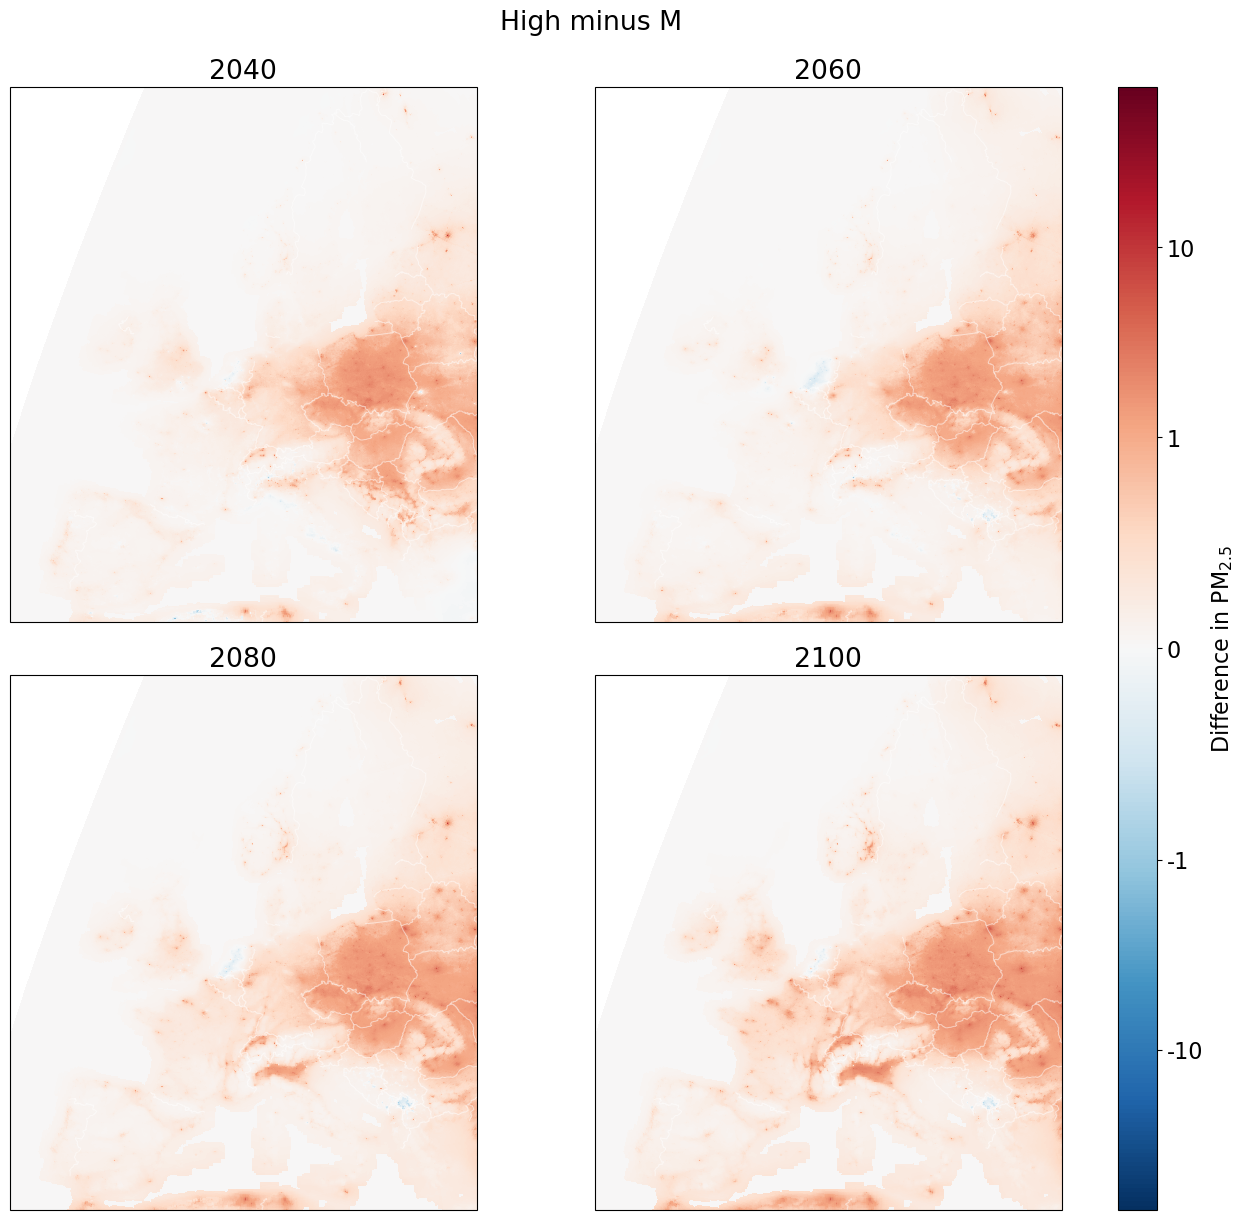

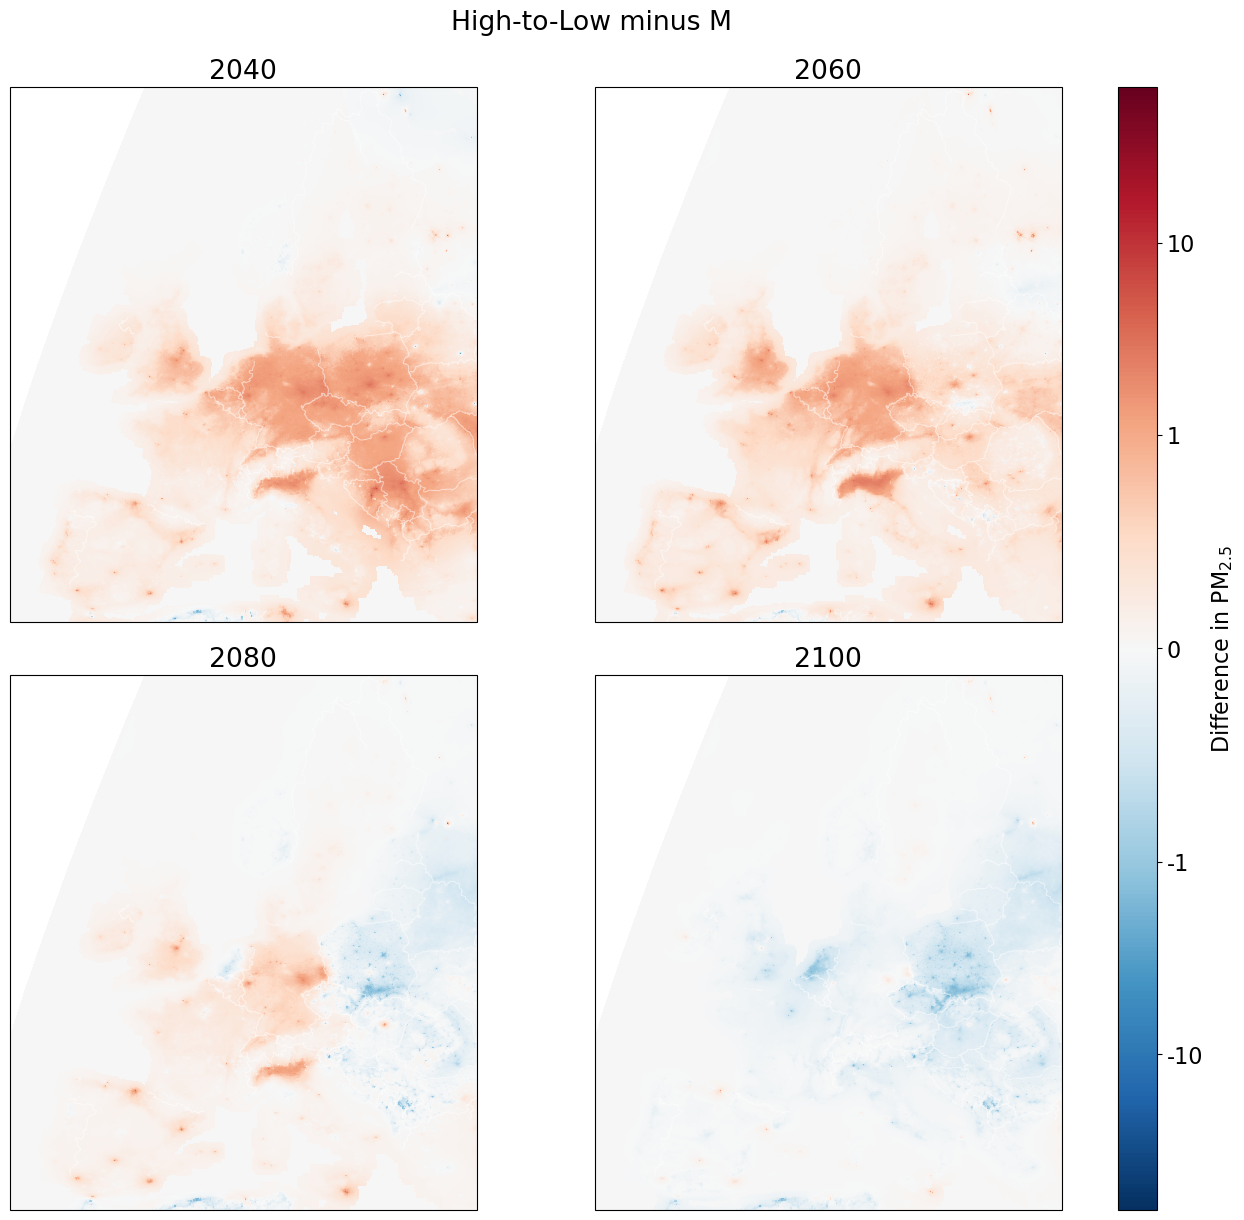

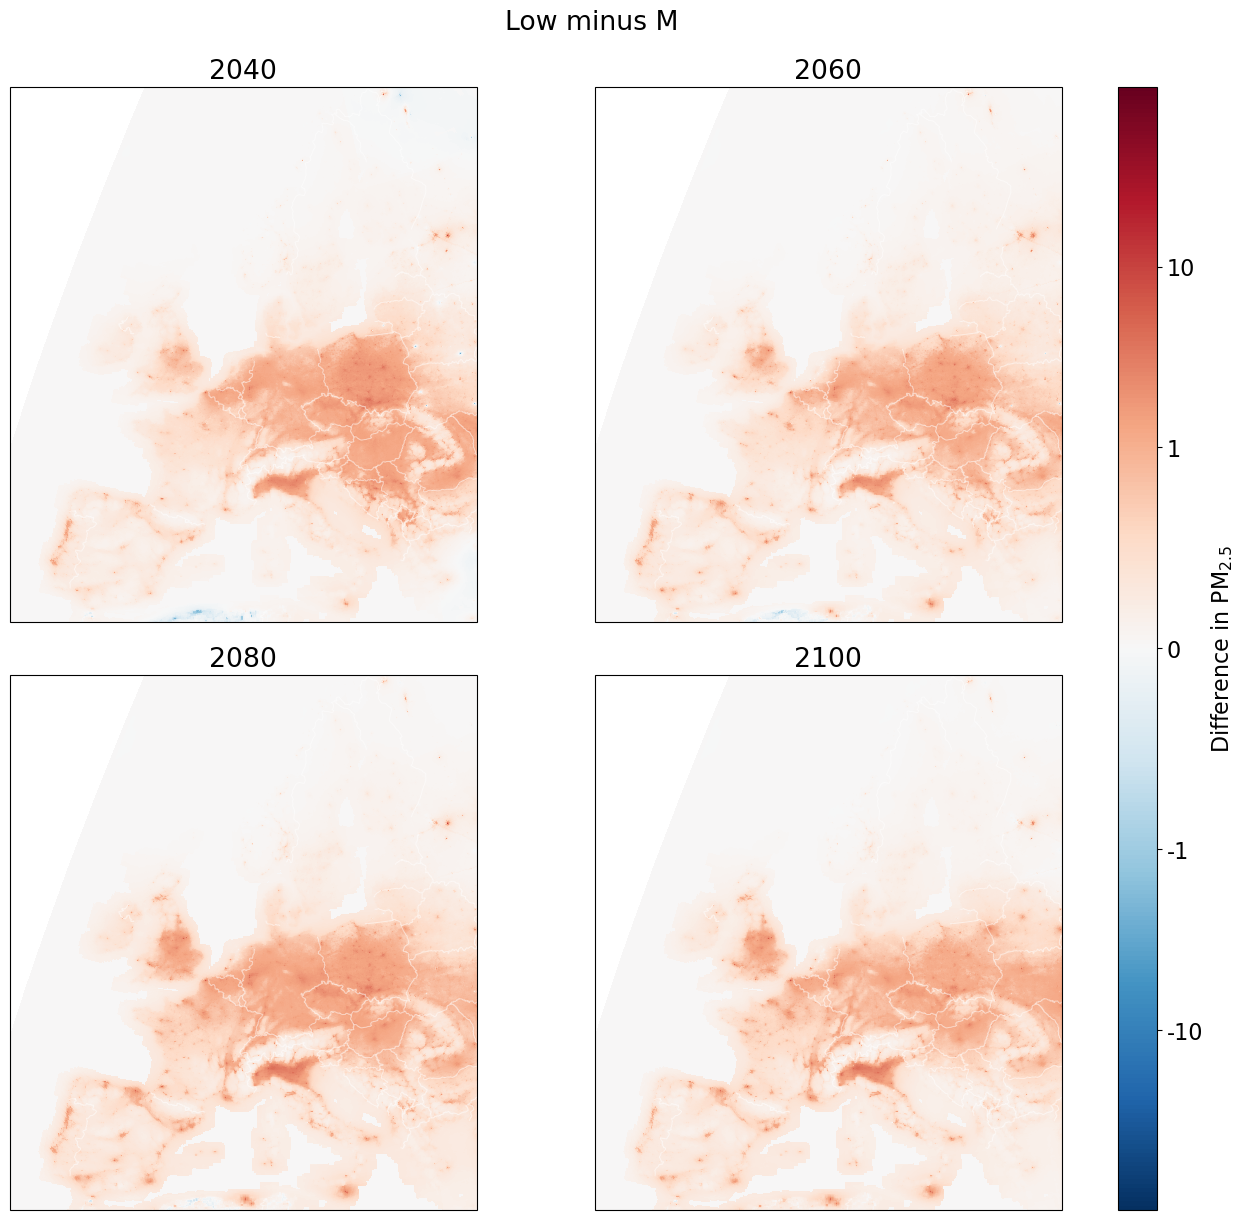

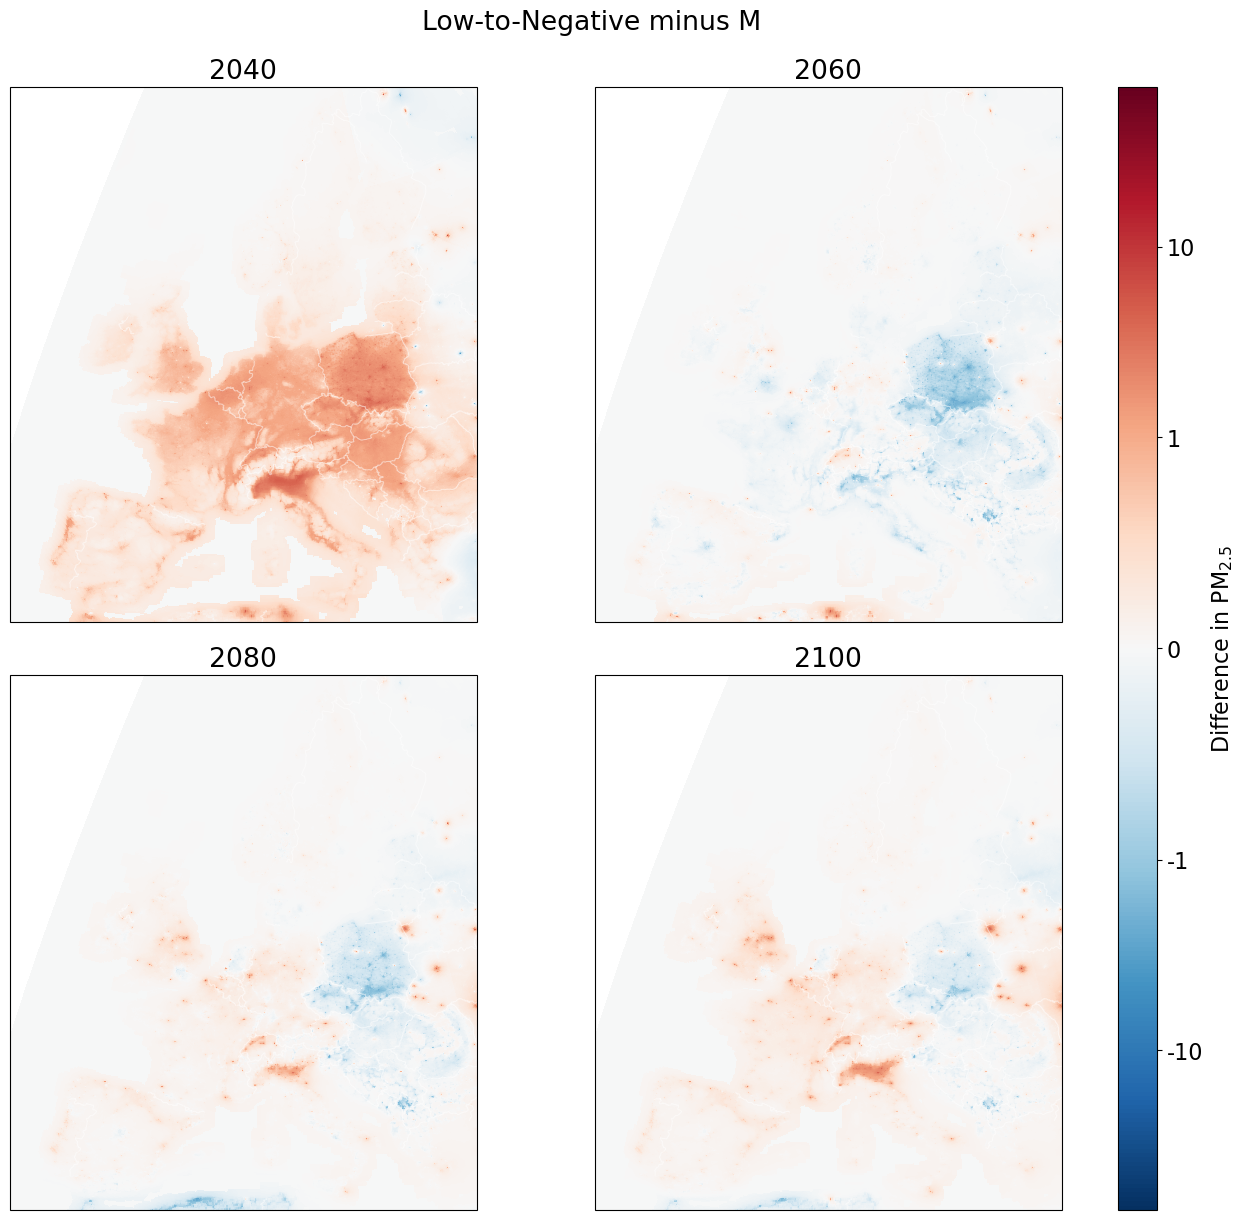

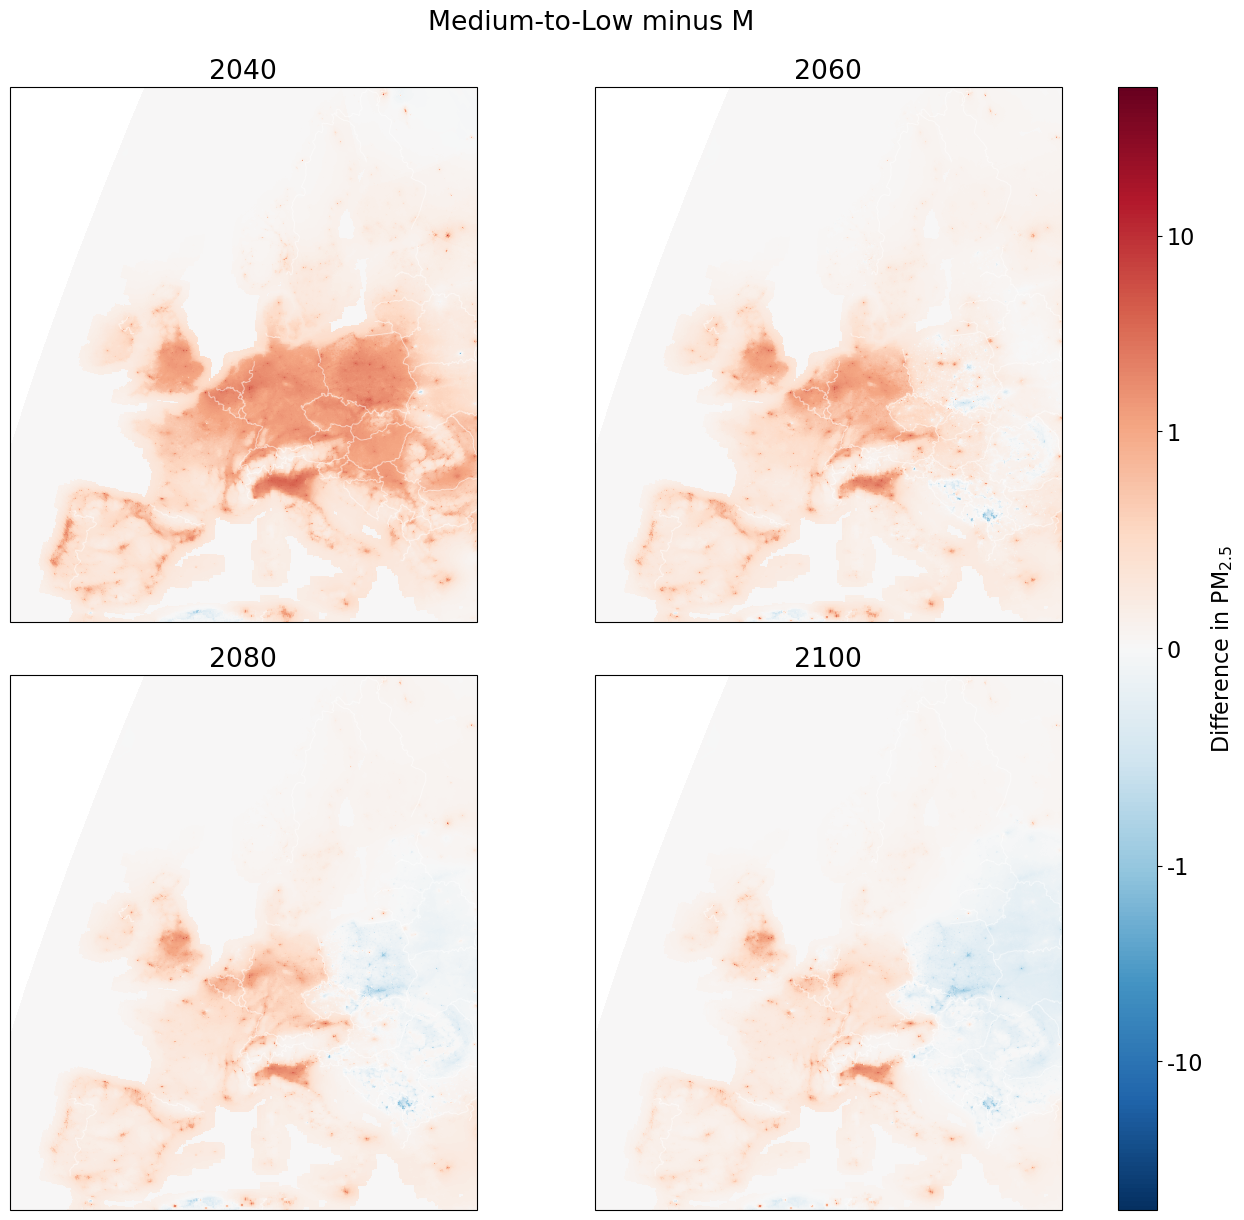

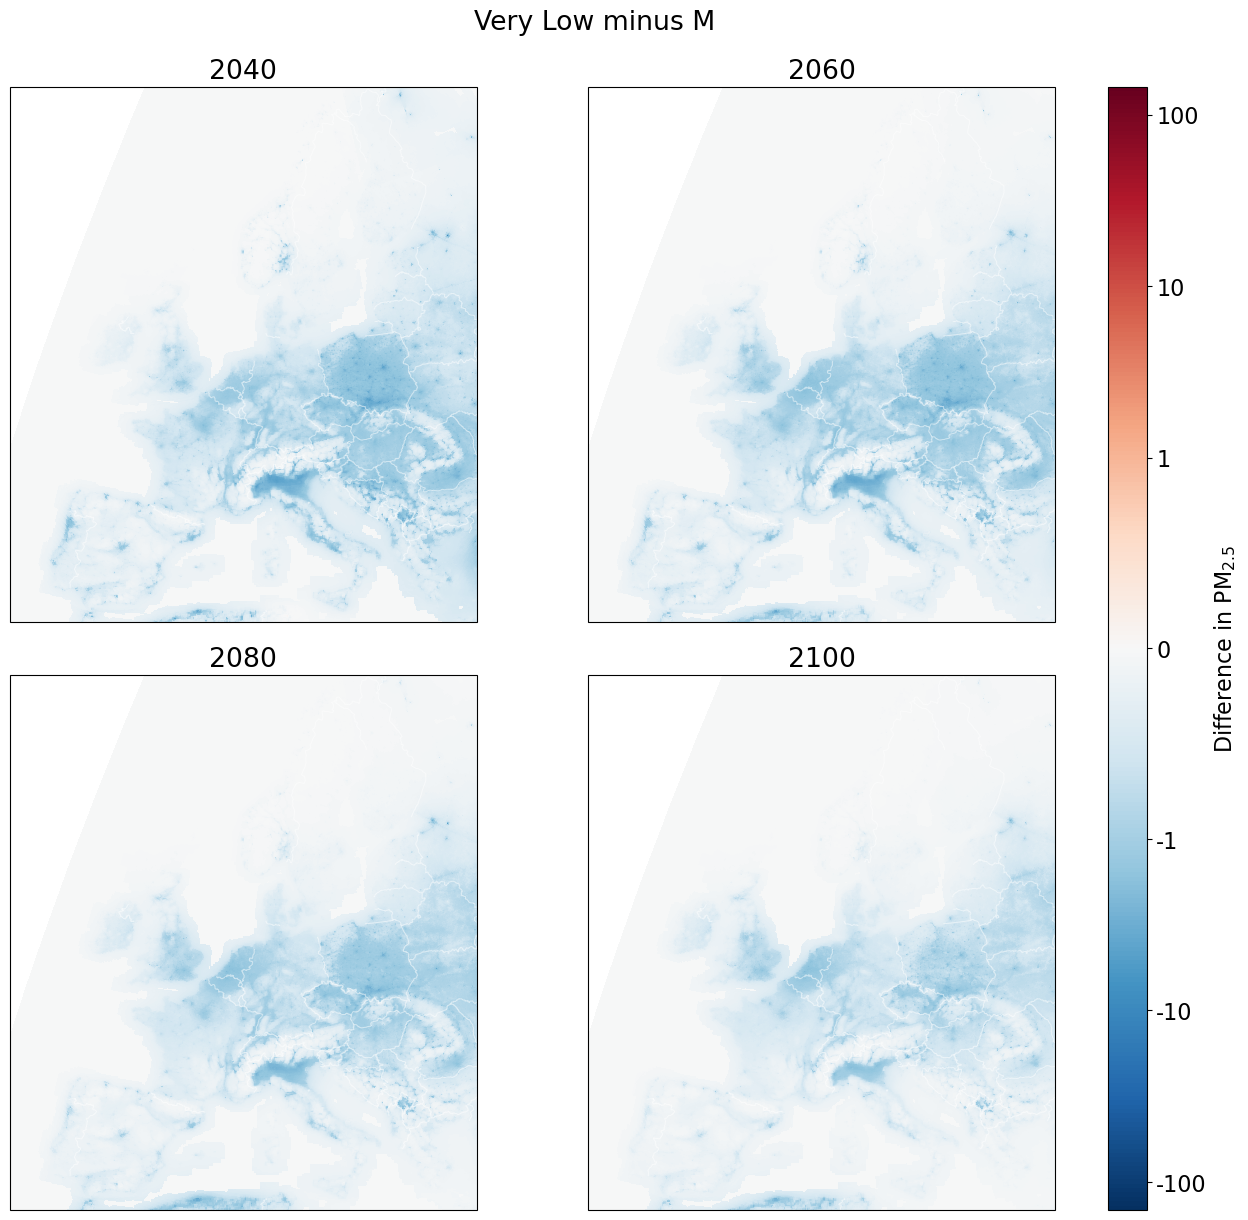

In [16]:
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "pm25" / "Annual_PM25")

scenarios = ["H", "HL", "L", "LN", "M", "ML", "VL"]
scenario_longname = ["High", "High-to-Low", "Low", "Low-to-Negative", "Medium", "Medium-to-Low", "Very Low"]
years = [2040, 2060, 2080, 2100]

select_scenario = "M"  # chosen comparison scenario

for scenario, scen_name in zip(scenarios, scenario_longname):
    if scenario == select_scenario:
        continue
    das = [load_pm25(scenario, year) - load_pm25(select_scenario, year) for year in years]
    plt.rcParams.update({'font.size': 16})
    plot_annual_pm25_diff(das, scenario, scen_name, select_scenario, years, SAVE_DIR)